In [1]:
! pip install opencv-python pixellib

## 제출 이미지  
1. 고양이 blur된 사진
2. 고양이랑 사막이 합쳐진 사진
3. 인물 사진

In [168]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt


# **1.고양이 blur 된 사진**

원본 고양이 이미지 크기: (3024, 4032, 3)
배경(사막) 이미지 크기: (1020, 1920, 3)


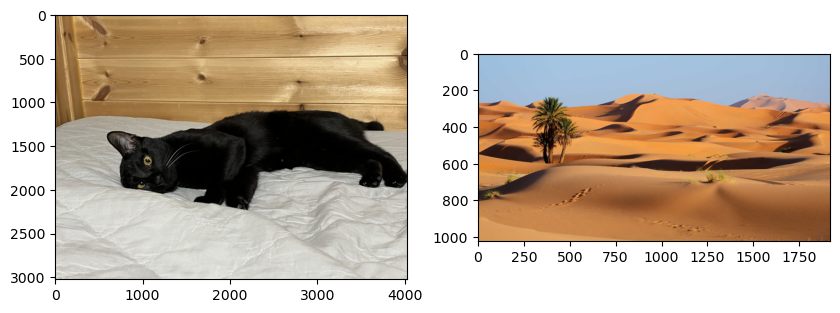

In [169]:
cat_img_path = "/home/jovyan/work/human_segmentation/images/cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "/home/jovyan/work/human_segmentation/images/sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [170]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)).unsqueeze(0)
input_tensor.shape


torch.Size([1, 3, 520, 520])

In [171]:
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)
output_predictions_resized.shape

(3024, 4032)

In [172]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

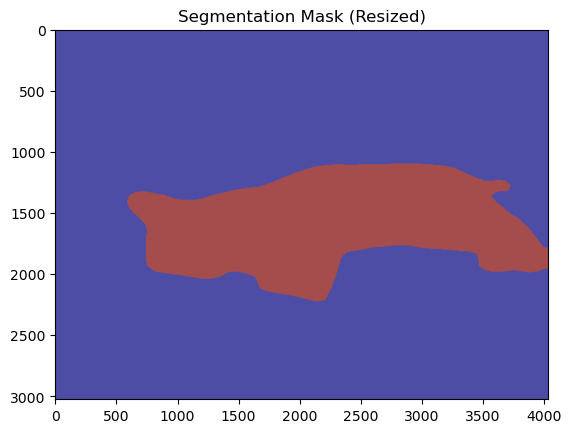

In [173]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [174]:
unique_classes = np.unique(output_predictions_resized)
seg_map = (output_predictions_resized == 8)  # 클래스 ID 8 (고양이)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

## 전체 블러 처리하기

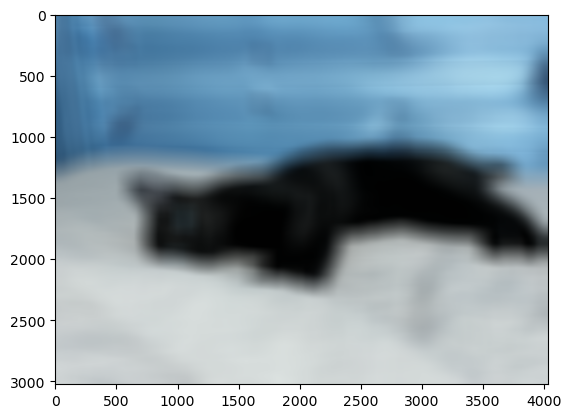

In [175]:
img_orig_blur = cv2.blur(cat_img, (200, 200))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

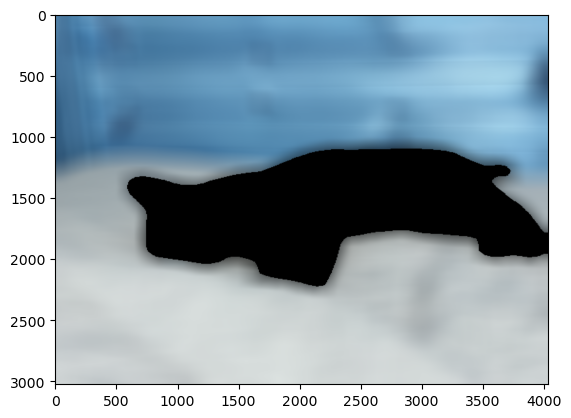

In [176]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

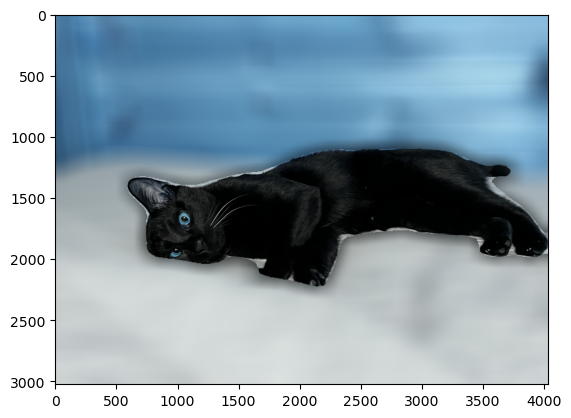

In [177]:

img_concat = np.where(img_mask_color==255, cat_img, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

# **2.고양이랑 사막이랑 합쳐진 사진**

예측된 클래스 ID: [0 8]


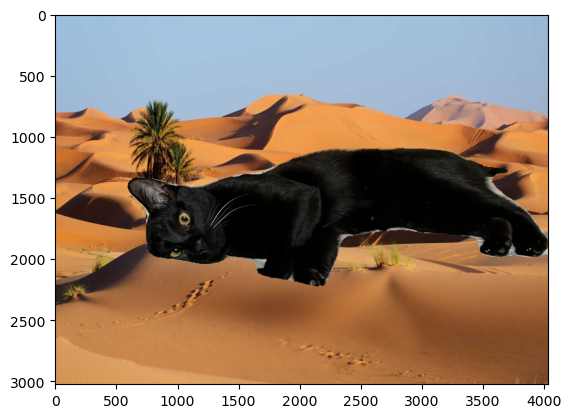

In [178]:

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255


# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

# **3. 인물 사진**

#### 사진 준비하기 (레드벨벳 - 조이)

이미지 크기: (1148, 1024, 3)


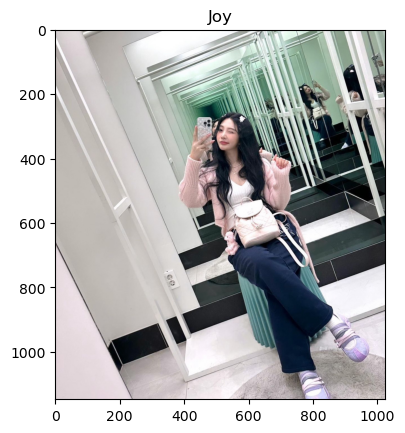

In [179]:

home_dir = os.getenv('HOME')
# img_path = os.path.join(home_dir, "work/human_segmentation/images/my_image.png")
img_path = os.path.join(home_dir, "work/human_segmentation/images/human.jpg")
img_orig = cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")


plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.title('Joy')
plt.show()

## **사전학습된 DeepLab 가져오기**

In [180]:
model = deeplabv3_resnet101(pretrained=True).eval()

In [181]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

In [182]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)
input_tensor.shape
#model

torch.Size([1, 3, 520, 520])

In [183]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)
output_predictions_resized.shape

CPU times: user 8 s, sys: 180 ms, total: 8.18 s
Wall time: 8.24 s


(1148, 1024)

In [184]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

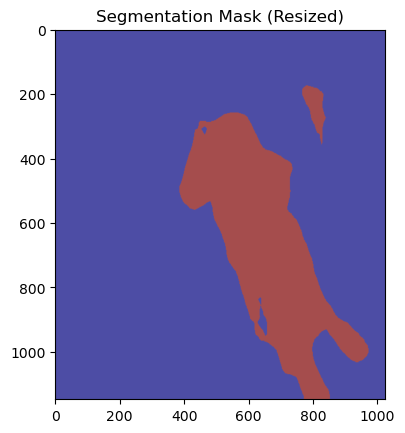

In [185]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

# **이미지 추출의 한계**  

- 인물과 사물(의자 + 폰)이 경계가 없이 같이 있는 경우 "person"으로 추출
- 반사된 거울의 인물 전신이 "person"으로 추출하기를 기대했지만, 거울의 경계가 나우어졌을 때 얼굴이 있는 거울 경계안만 "person"으로 인식
- 거울에 반사된 것 중 얼굴을 가지고 있는 거울 경계 중에서도 일부분만 "person" 으로 인식
- "person"으로 인식한 물건(의자 + 폰)의 일부분은 "background" 로 인식


 ### **마스킹이 명확하지 않다** 가 전체적인 한계인 것 같다

In [186]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [187]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [188]:
# 아래 코드를 이해하지 않아도 좋습니다
# PixelLib에서 그대로 가져온 코드입니다
# 주목해야 할 것은 생성 코드 결과물이예요!

#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

# colormap[:20]  # 생성한 20개의 컬러맵 출력

In [189]:
colormap[15]

array([192, 128, 128])

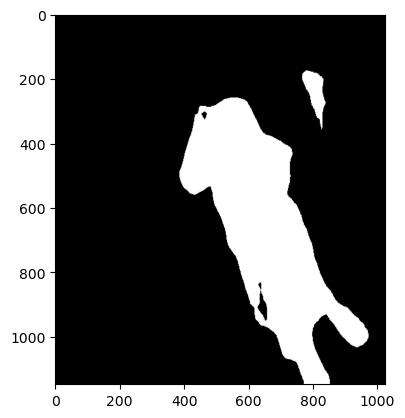

In [190]:

seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

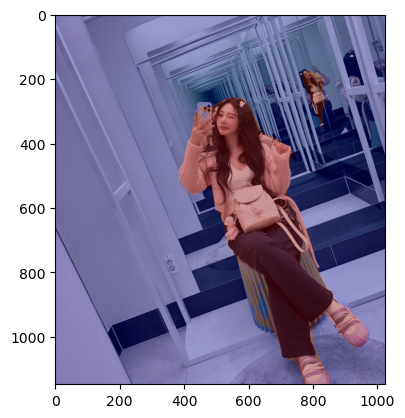

In [191]:
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

- 위에서 생각한 한계를 실제 이미지와 같이 보니, 더 명확하게 보인다

  ## **고민**
  - 거울의 경계선을 거울이라고 인식하면 나우어진 두 부분을 합쳐서 사람이라고 인식할까?


In [192]:
img_orig_blur = cv2.blur(img_orig, (20, 20))

# plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
# plt.show()

In [193]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)

## **아웃포커싱 된 인물**

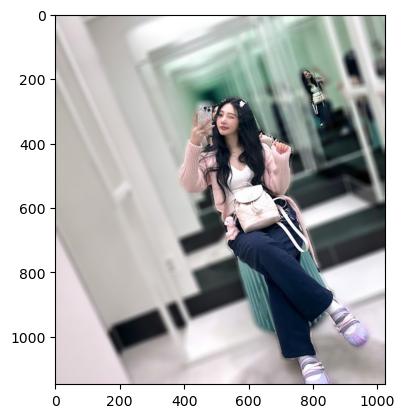

In [194]:
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

### blur 된 배경과 원본 인물과 합성하여 인물 사진 모드 생성이 되었다  
- 근데 만약 거울에 반사된 인물이 본인이 아니라 다른 사람(배경으로 취급)이라면 아웃포커싱 할 때 blur 처리 되길 원했을 수도

### **Output 거울 속 인물은 사람도 아니고 배경도 아니다**

## **해결1 - (거울 속 인물 날리기)** 
- 거울을 미리 masking 해서 인물로 받지 않는다(배경으로 처리)

- 거울은 보통 직선 경계 + 프레임
- Canny 로 거울 속 인물은 전처리 단계에서 blur 처리 해버리기

In [195]:
edges = cv2.Canny(img_orig, 100, 200)
kernel = np.ones((5,5), np.uint8)
edges_dilated = cv2.dilate(edges, kernel)
img_processed = img_orig.copy()
img_processed[edges_dilated > 0] = cv2.blur(img_orig, (15,15))[edges_dilated > 0]

In [196]:
test_input = transform(cv2.cvtColor(img_processed, cv2.COLOR_BGR2RGB)).unsqueeze(0)
test_input.shape

torch.Size([1, 3, 520, 520])

In [197]:
with torch.no_grad():
    output_test = model(test_input)["out"][0]
    output_predictions_test = output_test.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized_test = cv2.resize(output_predictions_test, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)
output_predictions_resized_test.shape

(1148, 1024)

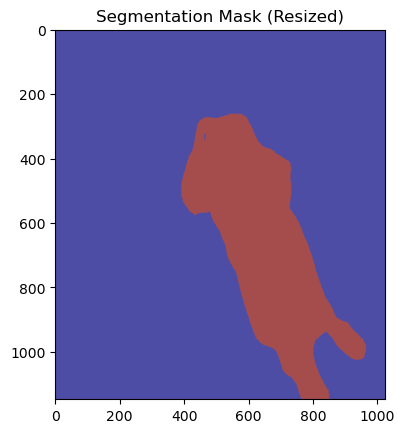

In [198]:
plt.imshow(output_predictions_resized_test, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

- 전처리 과정에서 blur 처리 되어서 그런가 의자는 오히려 명확하게 "person" 으로 인식되었다.
- 이전에는 의자는 backgrond + person으로 둘 가지 클래스로 공존했는데 지금은 오히려 깔끔하게 "person" 으로 인지

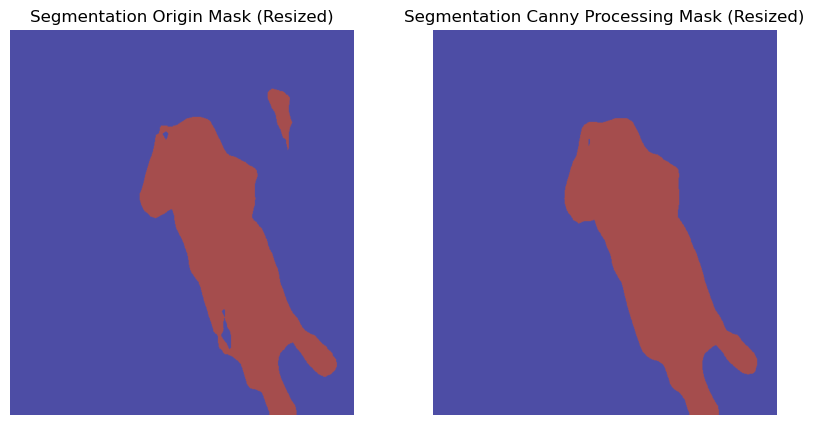

In [199]:
plt.figure(figsize=(10, 5))  

plt.subplot(1, 2, 1)
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Origin Mask (Resized)")
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(output_predictions_resized_test, cmap="jet", alpha=0.7)
plt.title("Segmentation Canny Processing Mask (Resized)")
plt.axis('off')

plt.show()

## **해결2 - (거울 속 인물 살리기) - 실패**
- 거울 속 인물은 사람으로 인식하게 해보기

# Sharpness 실패

In [200]:
import cv2

kernel = np.array([[0,-1,0],
                   [-1,9,-1],
                   [0,-1,0]])

img_sharp = cv2.filter2D(img_orig, -1, kernel)

In [201]:
test2_input = transform(cv2.cvtColor(img_sharp, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [202]:
with torch.no_grad():
    output_test2 = model(test2_input)["out"][0]
    output_predictions_test2 = output_test.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized_test2 = cv2.resize(output_predictions_test2, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)
output_predictions_resized_test2.shape

(1148, 1024)

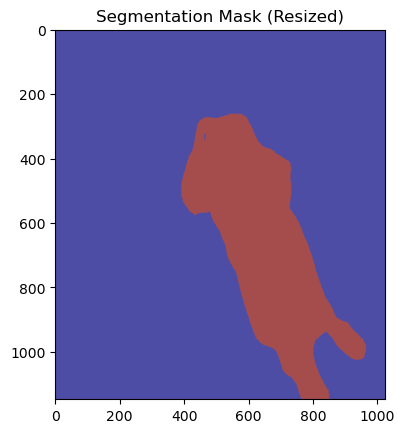

In [203]:
plt.imshow(output_predictions_resized_test2, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

# 채도 올리기

In [204]:
# BGR → HSV
hsv = cv2.cvtColor(img_orig, cv2.COLOR_BGR2HSV)

# 채널 분리
h, s, v = cv2.split(hsv)

# 채도 증가 (1.5배)
s = np.clip(s * 1.5, 0, 255).astype(np.uint8)

# 다시 합치기
hsv_enhanced = cv2.merge([h, s, v])

# HSV → BGR
img_saturation = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR)

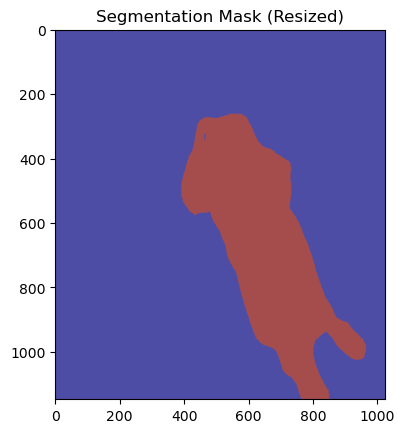

In [205]:
test2_input = transform(cv2.cvtColor(img_saturation, cv2.COLOR_BGR2RGB)).unsqueeze(0)
with torch.no_grad():
    output_test2 = model(test2_input)["out"][0]
    output_predictions_test2 = output_test.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized_test2 = cv2.resize(output_predictions_test2, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)
output_predictions_resized_test2.shape
plt.imshow(output_predictions_resized_test2, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

- 왜 해결하지 못할까 ..

## 논문에서는 Loss 를 추가해서 문제들 해결  
- Edge Loss
- Focal Loss
- Boundary Loss
- instance segmentatin  이용
- Transformer 이용